In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.functions import *
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import ClusteringEvaluator
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

In [2]:
spark = SparkSession.builder \
    .appName("RFM_Pipeline") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

26/04/19 11:51:50 WARN Utils: Your hostname, Jonathans-MacBook-Pro-16.local resolves to a loopback address: 127.0.0.1; using 192.168.100.197 instead (on interface en0)
26/04/19 11:51:50 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/19 11:51:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/19 11:51:52 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
pdf = pd.read_excel("../data/raw/online_retail_II.xlsx", engine="openpyxl")
df = spark.createDataFrame(pdf)

In [4]:
df_clean = (
    df
    # Drop entire row duplicates
    .dropDuplicates()
    
    # Drop rows with NaN in numerical columns
    # Drop rows with zero or non-positive Quantity or Price
    .filter(
        (~isnan("Quantity")) &
        (~isnan("Price")) &
        (~isnan("Customer ID")) &
        (col("Quantity") > 0) &
        (col("Price") > 0)
    )
    
    # Cast types safely
    .withColumn("Customer ID", col("Customer ID").cast("int"))
    .withColumn("Quantity", col("Quantity").cast("int"))
    .withColumn("TotalPrice", col("Quantity") * col("Price"))
    .withColumn("Date", F.to_date("InvoiceDate"))
)

print(f"Final clean dataset: {df_clean.count()} rows")
print(f"Number of rows removed: {df.count() - df_clean.count()}")
print(f"Number of duplicates removed: {df.count() - df.dropDuplicates().count()}")
print(f"Number of NaN rows removed: {df.count() - df.filter((~isnan('Quantity')) & (~isnan('Price')) & (~isnan('Customer ID'))).count()}")
print(f"Number of zero/negative values removed: {df.count() - df.filter((col('Quantity') > 0) & (col('Price') > 0)).count()}")
print(f"Number of rows with invalid Customer ID removed: {df.count() - df.filter(col('Customer ID').isNotNull()).count()}")
df_clean.show(5)


26/04/19 11:53:04 WARN TaskSetManager: Stage 0 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Final clean dataset: 400916 rows


26/04/19 11:53:09 WARN TaskSetManager: Stage 6 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 11:53:10 WARN TaskSetManager: Stage 9 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 11:53:12 WARN TaskSetManager: Stage 15 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Number of rows removed: 124545


26/04/19 11:53:12 WARN TaskSetManager: Stage 18 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 11:53:14 WARN TaskSetManager: Stage 24 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


...

Number of zero/negative values removed: 13895


26/04/19 11:53:17 WARN TaskSetManager: Stage 36 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 11:53:17 WARN TaskSetManager: Stage 39 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Number of rows with invalid Customer ID removed: 0


26/04/19 11:53:18 WARN TaskSetManager: Stage 42 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+------------------+----------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|        TotalPrice|      Date|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+------------------+----------+
| 489434|    85048|15CM CHRISTMAS GL...|      12|2009-12-01 07:45:00| 6.95|      13085|United Kingdom|              83.4|2009-12-01|
| 489434|    22041|RECORD FRAME 7" S...|      48|2009-12-01 07:45:00|  2.1|      13085|United Kingdom|100.80000000000001|2009-12-01|
| 489434|    22064|PINK DOUGHNUT TRI...|      24|2009-12-01 07:45:00| 1.65|      13085|United Kingdom|39.599999999999994|2009-12-01|
| 489434|    21523|FANCY FONT HOME S...|      10|2009-12-01 07:45:00| 5.95|      13085|United Kingdom|              59.5|2009-12-01|
| 489435|    22350|           CAT BOWL |      12|2009-12-01 07:46:00|

In [5]:
# Feature Engineering - RFM (Recency, Frequency, Monetary)
# Compute dataset max date FIRST (historical snapshot)
max_date = df_clean.agg(max("Date").alias("max_date")).collect()[0]["max_date"]
print(f"Dataset max date: {max_date}")

# RFM with correct Recency calculation
rfm = (df_clean
    .groupBy("Customer ID", "Country")
    .agg(
        datediff(lit(max_date), max("Date")).alias("Recency"),    # Days from customer's last purchase to DATASET END
        countDistinct("Invoice").alias("Frequency"),              # Unique invoices per customer
        round(sum("TotalPrice"), 2).alias("Monetary")             # Total lifetime spend
    )
    .filter((col("Recency") >= 0) & (col("Recency") <= 365))      # Active customers (0-365 days)
)

print("\\nRFM Features (Corrected):")
rfm.orderBy(desc("Monetary")).show(10)
print(f"Generated RFM for {rfm.count()} unique customers")

26/04/19 11:53:21 WARN TaskSetManager: Stage 45 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Dataset max date: 2010-12-09
\nRFM Features (Corrected):


26/04/19 11:53:22 WARN TaskSetManager: Stage 48 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 11:53:24 WARN TaskSetManager: Stage 58 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


+-----------+--------------+-------+---------+---------+
|Customer ID|       Country|Recency|Frequency| Monetary|
+-----------+--------------+-------+---------+---------+
|      18102|United Kingdom|      0|       89|349164.35|
|      14646|   Netherlands|      9|       78| 248396.5|
|      14156|          EIRE|      6|      102|196549.74|
|      14911|          EIRE|      0|      205|152121.22|
|      13694|United Kingdom|      8|       94|131443.19|
|      17511|United Kingdom|      2|       31| 84541.17|
|      15061|United Kingdom|      2|       86| 83284.38|
|      16684|United Kingdom|     14|       27| 80489.21|
|      16754|United Kingdom|      7|       29| 65500.07|
|      17949|United Kingdom|      6|       74|  60117.6|
+-----------+--------------+-------+---------+---------+
only showing top 10 rows



Generated RFM for 4262 unique customers


In [6]:
# MLlib Pipeline
assembler = VectorAssembler(inputCols=["Recency", "Frequency", "Monetary"], outputCol="features")
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")
kmeans = KMeans(k=5, seed=42, featuresCol="scaledFeatures")

pipeline = Pipeline(stages=[assembler, scaler, kmeans])
model = pipeline.fit(rfm)

26/04/19 11:53:26 WARN TaskSetManager: Stage 64 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 11:53:28 WARN TaskSetManager: Stage 79 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 11:53:30 WARN TaskSetManager: Stage 85 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 11:53:31 WARN TaskSetManager: Stage 100 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 11:53:34 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/19 11:53:34 WARN TaskSetManager: Stage 235 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


In [7]:
# 80/20 train/test split
train, test = rfm.randomSplit([0.8, 0.2], seed=42)
predictions = model.transform(test)

# Silhouette Score (cluster quality)
evaluator = ClusteringEvaluator(featuresCol="scaledFeatures")
silhouette = evaluator.evaluate(predictions)
print(f"Silhouette Score: {silhouette:.3f} (>0.5 = good clusters)")

# Business validation: Pareto Rule
revenue_by_cluster = predictions.groupBy("prediction").agg(round(mean("Monetary"), 2).alias("Avg_LTV")).orderBy(desc("Avg_LTV"))
revenue_by_cluster.show()
print(f"Average LTV per cluster: {revenue_by_cluster.collect()[0]['Avg_LTV']}")

26/04/19 11:53:36 WARN TaskSetManager: Stage 250 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 11:53:37 WARN TaskSetManager: Stage 261 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 11:53:38 WARN TaskSetManager: Stage 276 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Silhouette Score: 0.482 (>0.5 = good clusters)


26/04/19 11:53:39 WARN TaskSetManager: Stage 291 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


+----------+---------+
|prediction|  Avg_LTV|
+----------+---------+
|         2|163996.47|
|         1| 37461.46|
|         4|  1981.52|
|         0|   818.12|
|         3|   580.42|
+----------+---------+



Average LTV per cluster: 163996.47


In [8]:
# Export High-Value Segment (Cluster 0)
high_value = predictions \
    .filter(col("prediction") == 0) \
    .select("Customer ID", "Country", "Recency", "Frequency", "Monetary")

# Count BEFORE writing (write returns None)
count = high_value.count()

high_value.write.csv("../data/outputs/high_value_customers", header=True, mode="overwrite")

print(f"Pipeline COMPLETE: {count} high-value customers exported")
# spark.stop()

26/04/19 11:53:41 WARN TaskSetManager: Stage 317 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 11:53:42 WARN TaskSetManager: Stage 332 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Pipeline COMPLETE: 160 high-value customers exported


## Visualization
### 2D Scatter Plot

26/04/19 11:56:37 WARN TaskSetManager: Stage 342 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


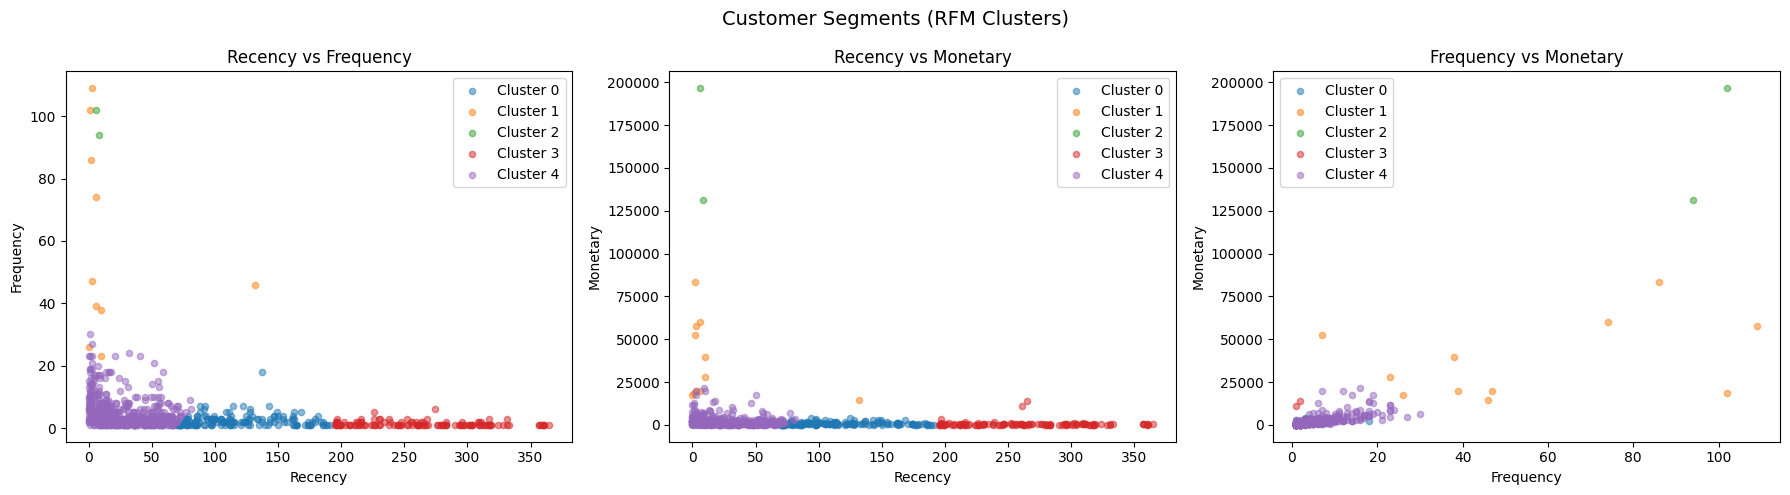

In [9]:
# 2D scatterplot
pdf = predictions.select("Recency", "Frequency", "Monetary", "prediction").toPandas()

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [("Recency", "Frequency"), ("Recency", "Monetary"), ("Frequency", "Monetary")]

for ax, (x_col, y_col) in zip(axes, pairs):
    for cluster in sorted(pdf["prediction"].unique()):
        subset = pdf[pdf["prediction"] == cluster]
        ax.scatter(subset[x_col], subset[y_col], label=f"Cluster {cluster}", alpha=0.5, s=20)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.legend()
    ax.set_title(f"{x_col} vs {y_col}")

plt.suptitle("Customer Segments (RFM Clusters)", fontsize=14)
plt.tight_layout()
plt.show()

### 3D Scatter Plot

26/04/19 11:57:39 WARN TaskSetManager: Stage 352 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


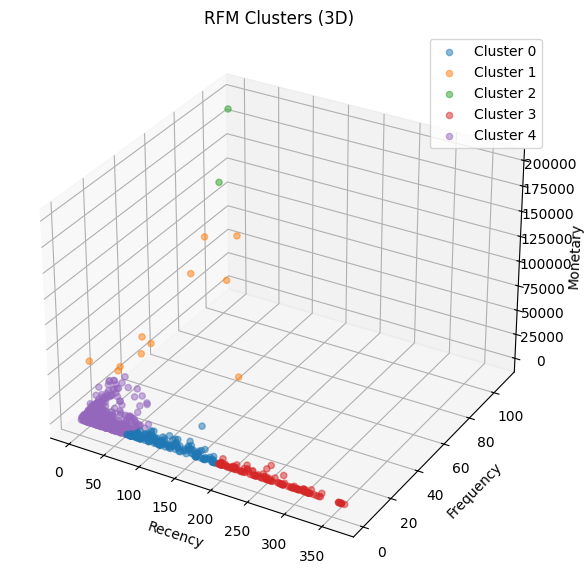

In [11]:
pdf = predictions.select("Recency", "Frequency", "Monetary", "prediction").toPandas()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for cluster in sorted(pdf["prediction"].unique()):
    subset = pdf[pdf["prediction"] == cluster]
    ax.scatter(subset["Recency"], subset["Frequency"], subset["Monetary"],
               label=f"Cluster {cluster}", alpha=0.5, s=20)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")
ax.legend()
ax.set_title("RFM Clusters (3D)")
plt.show()

### PCA

26/04/19 11:58:20 WARN TaskSetManager: Stage 362 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


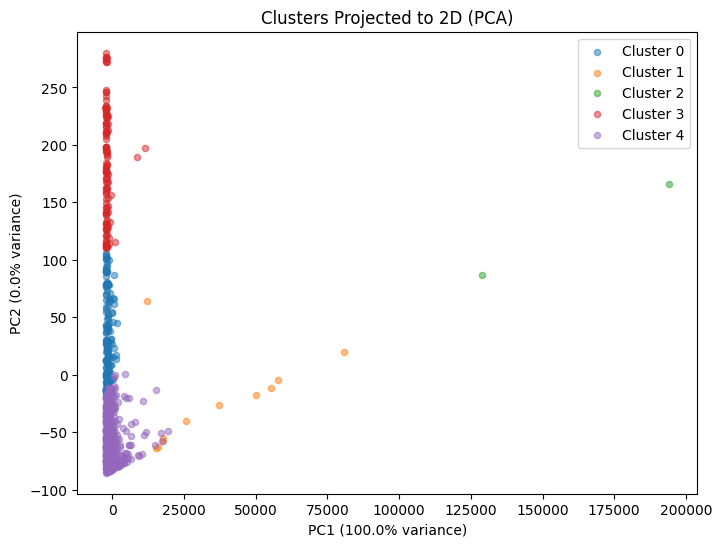

In [13]:
pdf = predictions.select("features", "prediction").toPandas()

# Extract feature vectors
import numpy as np
X = np.array(pdf["features"].apply(lambda v: v.toArray()).tolist())

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
for cluster in sorted(pdf["prediction"].unique()):
    mask = pdf["prediction"] == cluster
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=f"Cluster {cluster}", alpha=0.5, s=20)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend()
plt.title("Clusters Projected to 2D (PCA)")
plt.show()

### Cluster Profiles

26/04/19 11:58:37 WARN TaskSetManager: Stage 372 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


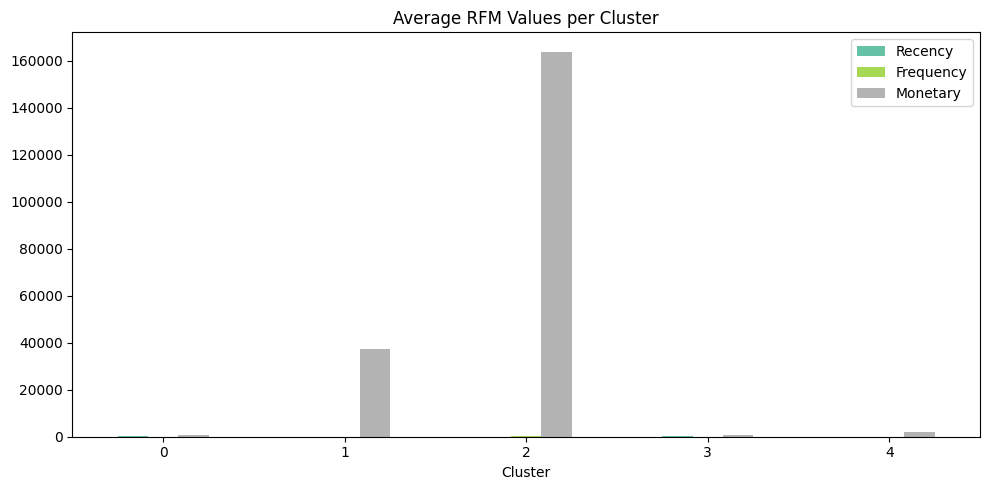

In [14]:
pdf = predictions.select("Recency", "Frequency", "Monetary", "prediction").toPandas()

profile = pdf.groupby("prediction")[["Recency", "Frequency", "Monetary"]].mean()

profile.plot(kind="bar", figsize=(10, 5), colormap="Set2")
plt.title("Average RFM Values per Cluster")
plt.xlabel("Cluster")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

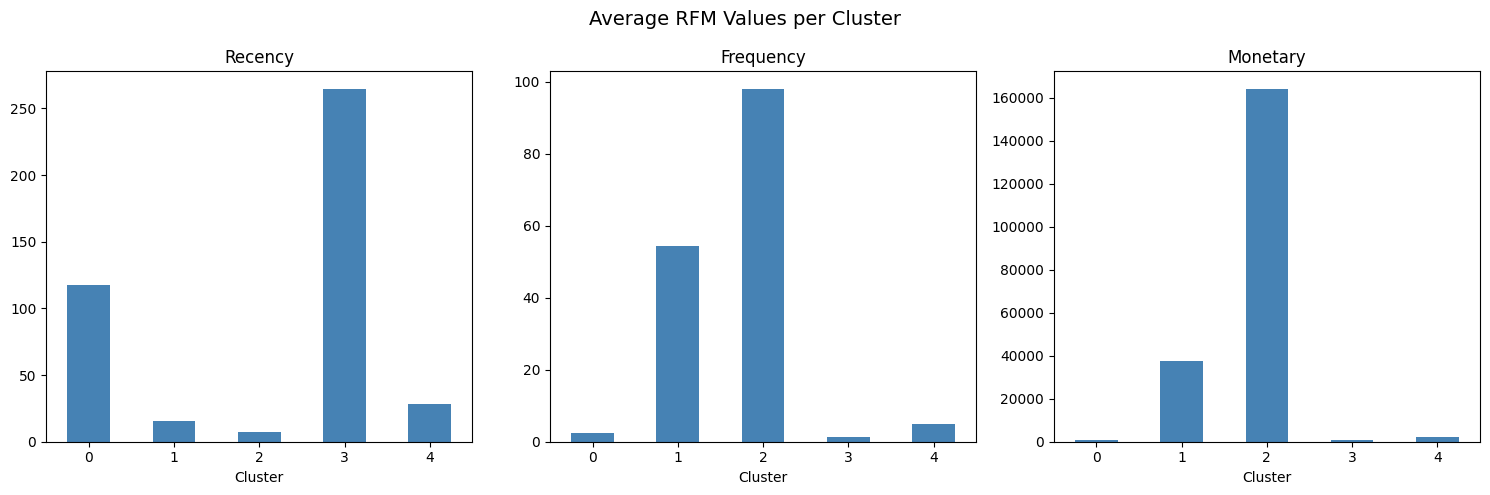

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    profile[col].plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("Cluster")
    ax.set_xticks(range(len(profile)))
    ax.set_xticklabels(profile.index, rotation=0)

plt.suptitle("Average RFM Values per Cluster", fontsize=14)
plt.tight_layout()
plt.show()

26/04/19 12:02:59 WARN TaskSetManager: Stage 382 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


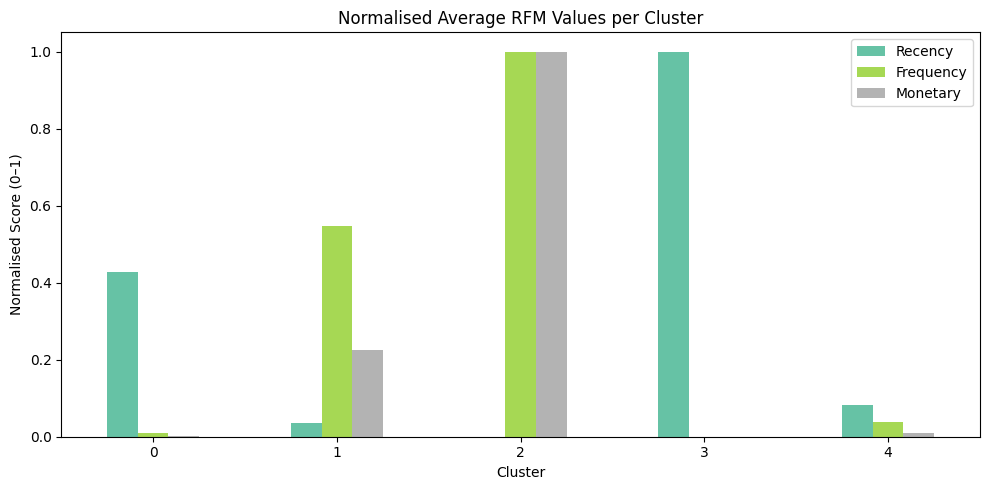

In [16]:
pdf = predictions.select("Recency", "Frequency", "Monetary", "prediction").toPandas()

profile = pdf.groupby("prediction")[["Recency", "Frequency", "Monetary"]].mean()

# Normalize each column to 0–1 scale so all three are visible
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

profile_norm.plot(kind="bar", figsize=(10, 5), colormap="Set2")
plt.title("Normalised Average RFM Values per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Normalised Score (0–1)")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Model Improvements

In [18]:
# OUTLIER REMOVAL
def remove_outliers(df, col_name):
    quantiles = df.approxQuantile(col_name, [0.01, 0.99], 0.01)
    return df.filter((col(col_name) >= quantiles[0]) & (col(col_name) <= quantiles[1]))

rfm_clean = rfm
for c in ["Recency", "Frequency", "Monetary"]:
    rfm_clean = remove_outliers(rfm_clean, c)

print(f"After outlier removal: {rfm_clean.count()} customers")

26/04/19 12:19:18 WARN TaskSetManager: Stage 392 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:19:23 WARN TaskSetManager: Stage 395 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:19:24 WARN TaskSetManager: Stage 401 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:19:26 WARN TaskSetManager: Stage 411 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


After outlier removal: 4262 customers


In [19]:
# LOG TRANSFORM (to fix right-skew in Frequency & Monetary)
rfm_log = (rfm_clean
    .withColumn("Recency",   log1p(col("Recency")))    
    .withColumn("Frequency", log1p(col("Frequency")))
    .withColumn("Monetary",  log1p(col("Monetary")))
)

In [20]:
# FIND OPTIMAL K (Elbow + Silhouette)
assembler = VectorAssembler(inputCols=["Recency", "Frequency", "Monetary"], outputCol="features")
scaler    = StandardScaler(inputCol="features", outputCol="scaledFeatures")

k_range       = range(2, 10)
silhouettes   = []
wssse_scores  = []
evaluator     = ClusteringEvaluator(featuresCol="scaledFeatures")

for k in k_range:
    kmeans    = KMeans(k=k, seed=42, featuresCol="scaledFeatures", maxIter=50)
    pipeline  = Pipeline(stages=[assembler, scaler, kmeans])
    m         = pipeline.fit(rfm_log)
    preds     = m.transform(rfm_log)

    sil = evaluator.evaluate(preds)
    wss = m.stages[-1].summary.trainingCost    

    silhouettes.append(sil)
    wssse_scores.append(wss)
    print(f"k={k}  Silhouette={sil:.3f}  WSSSE={wss:,.0f}")

26/04/19 12:20:25 WARN TaskSetManager: Stage 426 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:27 WARN TaskSetManager: Stage 441 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:28 WARN TaskSetManager: Stage 447 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:29 WARN TaskSetManager: Stage 462 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:31 WARN TaskSetManager: Stage 557 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:32 WARN TaskSetManager: Stage 572 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:33 WARN TaskSetManager: Stage 583 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.

k=2  Silhouette=0.611  WSSSE=6,582


26/04/19 12:20:36 WARN TaskSetManager: Stage 613 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:37 WARN TaskSetManager: Stage 619 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:38 WARN TaskSetManager: Stage 634 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:40 WARN TaskSetManager: Stage 774 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:41 WARN TaskSetManager: Stage 789 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:42 WARN TaskSetManager: Stage 800 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:43 WARN TaskSetManager: Stage 815 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.

k=3  Silhouette=0.491  WSSSE=4,980


26/04/19 12:20:44 WARN TaskSetManager: Stage 830 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:45 WARN TaskSetManager: Stage 836 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:46 WARN TaskSetManager: Stage 851 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:48 WARN TaskSetManager: Stage 1041 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:49 WARN TaskSetManager: Stage 1056 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:50 WARN TaskSetManager: Stage 1067 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:20:51 WARN TaskSetManager: Stage 1082 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 

...

k=7  Silhouette=0.419  WSSSE=2,703


26/04/19 12:21:18 WARN TaskSetManager: Stage 1898 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:21:19 WARN TaskSetManager: Stage 1904 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:21:20 WARN TaskSetManager: Stage 1919 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:21:23 WARN TaskSetManager: Stage 2204 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:21:24 WARN TaskSetManager: Stage 2219 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:21:25 WARN TaskSetManager: Stage 2230 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:21:27 WARN TaskSetManager: Stage 2245 contains a task of very large size (2092 KiB). The maximum recommended task size is 10

k=8  Silhouette=0.424  WSSSE=2,437


26/04/19 12:21:28 WARN TaskSetManager: Stage 2260 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:21:29 WARN TaskSetManager: Stage 2266 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:21:30 WARN TaskSetManager: Stage 2281 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:21:32 WARN TaskSetManager: Stage 2476 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:21:33 WARN TaskSetManager: Stage 2491 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:21:34 WARN TaskSetManager: Stage 2502 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


k=9  Silhouette=0.444  WSSSE=2,240


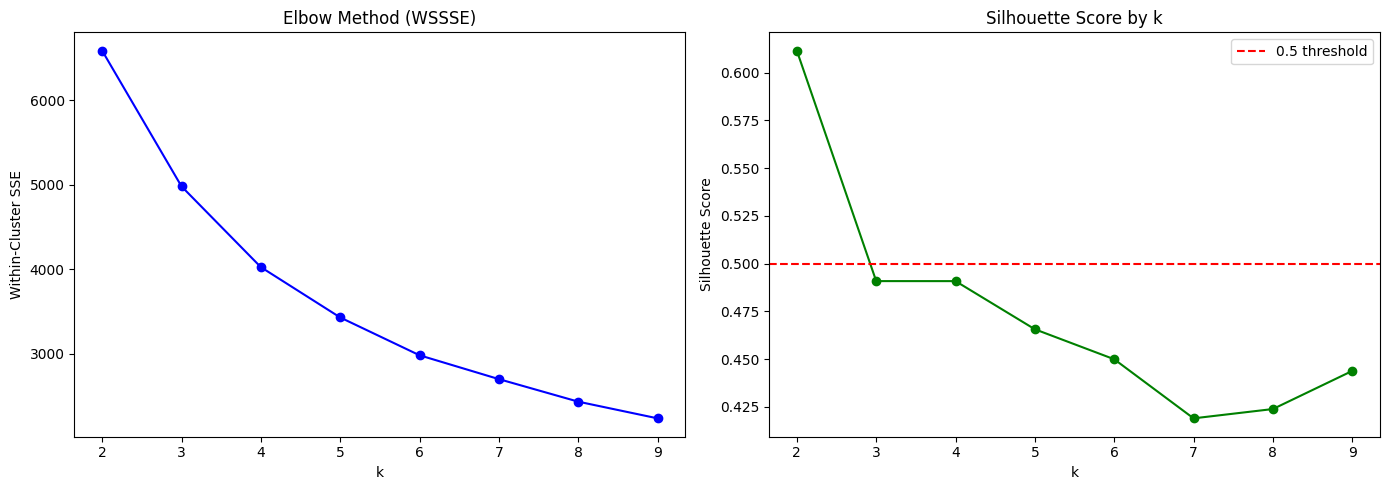

In [21]:
# Plot elbow + silhouette together
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), wssse_scores, "bo-")
ax1.set_title("Elbow Method (WSSSE)")
ax1.set_xlabel("k")
ax1.set_ylabel("Within-Cluster SSE")

ax2.plot(list(k_range), silhouettes, "go-")
ax2.axhline(y=0.5, color="red", linestyle="--", label="0.5 threshold")
ax2.set_title("Silhouette Score by k")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette Score")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# FIT FINAL MODEL WITH BEST K
best_k = k_range[np.argmax(silhouettes)]
print(f"\nBest k by silhouette: {best_k}")

kmeans_final = KMeans(k=best_k, seed=42, featuresCol="scaledFeatures",
                      maxIter=100,          
                      initMode="k-means||") 

pipeline_final = Pipeline(stages=[assembler, scaler, kmeans_final])


Best k by silhouette: 2


In [23]:
# CORRECT TRAIN/TEST SPLIT
train, test = rfm_log.randomSplit([0.8, 0.2], seed=42)

model_final  = pipeline_final.fit(train)        # fit on train only
predictions  = model_final.transform(test)      # evaluate on unseen test

silhouette_final = evaluator.evaluate(predictions)
print(f"Final Silhouette Score: {silhouette_final:.3f}")

26/04/19 12:23:19 WARN TaskSetManager: Stage 2517 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:23:21 WARN TaskSetManager: Stage 2532 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:23:23 WARN TaskSetManager: Stage 2538 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:23:25 WARN TaskSetManager: Stage 2553 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:23:27 WARN TaskSetManager: Stage 2643 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:23:28 WARN TaskSetManager: Stage 2658 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 12:23:29 WARN TaskSetManager: Stage 2669 contains a task of very large size (2092 KiB). The maximum recommended task size is 10

Final Silhouette Score: 0.593


26/04/19 12:26:42 WARN TaskSetManager: Stage 2684 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


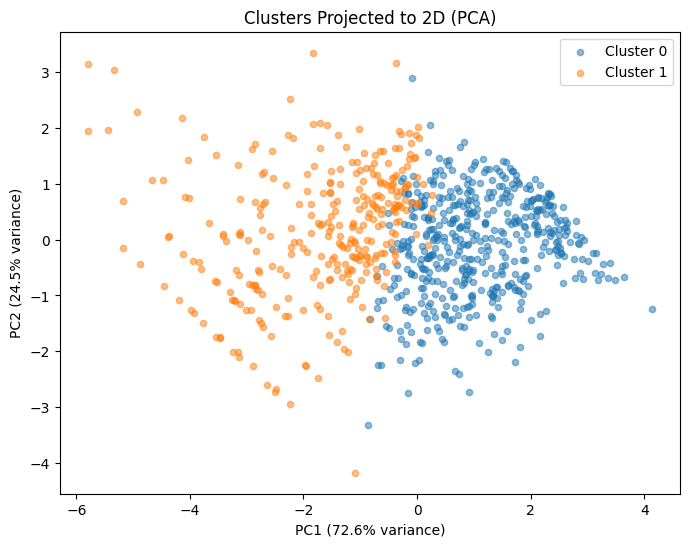

In [24]:
pdf = predictions.select("features", "prediction").toPandas()

# Extract feature vectors
import numpy as np
X = np.array(pdf["features"].apply(lambda v: v.toArray()).tolist())

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
for cluster in sorted(pdf["prediction"].unique()):
    mask = pdf["prediction"] == cluster
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=f"Cluster {cluster}", alpha=0.5, s=20)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend()
plt.title("Clusters Projected to 2D (PCA)")
plt.show()